# Model 2: Advanced Decision Tree Classification
Decision trees natively handle non-linear relationships and feature interactions without requiring data scaling. However, they are highly prone to **overfitting**. Therefore, this analysis will go beyond a simple baseline model. I will conduct rigorous hyperparameter tuning, visualize the bias-variance tradeoff, and apply Cost-Complexity Pruning to build an optimized, robust model.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE


In [16]:
df = pd.read_csv('../data/final/ml_ready_dataset.csv')

X = df.select_dtypes(exclude=['object', 'string']).drop(columns=['is_returned'], errors='ignore')
y = df['is_returned']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Original training shape: {X_train.shape}")
print(f"SMOTE resampled training shape: {X_train_resampled.shape}")

Original training shape: (77599, 39)
SMOTE resampled training shape: (127196, 39)


###  Danger of Overfitting (Unconstrained Tree)
train a completely unconstrained Decision Tree. This allows the tree to grow until every single leaf is pure. this achieve near 100% accuracy on the training data, but perform poorly on the test data—a classic demonstration of **high variance (overfitting)**.

In [17]:
unconstrained_dt = DecisionTreeClassifier(random_state=42)
unconstrained_dt.fit(X_train_resampled, y_train_resampled)

train_acc = accuracy_score(y_train_resampled, unconstrained_dt.predict(X_train_resampled))
test_acc = accuracy_score(y_test, unconstrained_dt.predict(X_test))

print(f"Unconstrained Tree Training Accuracy: {train_acc * 100:.2f}%")
print(f"Unconstrained Tree Testing Accuracy: {test_acc * 100:.2f}%")
print(f"Tree Depth Achieved: {unconstrained_dt.get_depth()} levels")
print(f"Total Leaves Created: {unconstrained_dt.get_n_leaves()} leaves")

Unconstrained Tree Training Accuracy: 99.98%
Unconstrained Tree Testing Accuracy: 84.45%
Tree Depth Achieved: 43 levels
Total Leaves Created: 8417 leaves


### Visualizing the Bias-Variance Tradeoff
To find the "sweet spot" between underfitting and overfitting, i take different `max_depth` limits and plot the resulting training vs. testing accuracy.

In [ ]:
depths = range(1, 25)
train_scores = []
test_scores = []

for d in depths:
    temp_dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    temp_dt.fit(X_train_resampled, y_train_resampled)
    train_scores.append(accuracy_score(y_train_resampled, temp_dt.predict(X_train_resampled)))
    test_scores.append(accuracy_score(y_test, temp_dt.predict(X_test)))

plt.figure(figsize=(12, 6))
plt.plot(depths, train_scores, label='Training Accuracy', color='blue', marker='o')
plt.plot(depths, test_scores, label='Testing Accuracy', color='red', marker='s')
plt.title('Bias-Variance Tradeoff: Optimizing Tree Depth', fontsize=16, fontweight='bold')
plt.xlabel('Maximum Tree Depth')
plt.ylabel('Accuracy')
plt.xticks(depths)
plt.legend()
plt.show()

### Hyperparameter Tuning with GridSearchCV
Let's deploy `GridSearchCV` to run 5-fold cross-validation across a matrix of hyperparameters, evaluating both depth and leaf splitting constraints simultaneously.

In [ ]:
param_grid = {
    'max_depth': [3, 5, 7,8,9,10],
    'min_samples_split': [10, 50, 100],
    'min_samples_leaf': [5, 20, 50],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_search.fit(X_train_resampled, y_train_resampled)
best_dt = grid_search.best_estimator_

print(f"Best Hyperparameters Discovered: {grid_search.best_params_}")
print(f"Best Cross-Validated ROC-AUC: {grid_search.best_score_:.4f}")

Best Hyperparameters Discovered: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 100}
Best Cross-Validated ROC-AUC: 0.9510


### Evaluating the Optimized Model
Using the optimized estimator from our Grid Search, generate the final predictions on test set and plot the Confusion Matrix.

Optimized Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.96      0.94     15900
           1       0.78      0.67      0.72      3500

    accuracy                           0.91     19400
   macro avg       0.85      0.81      0.83     19400
weighted avg       0.90      0.91      0.90     19400

Final ROC-AUC Score: 0.8871



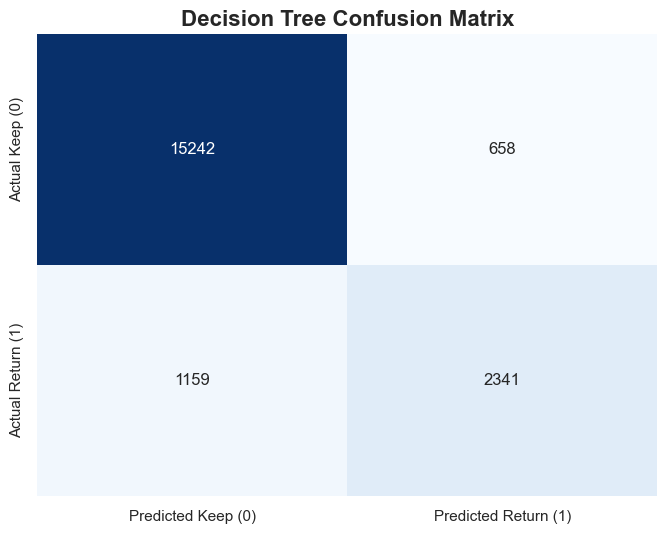

In [ ]:
preds = best_dt.predict(X_test)
probs = best_dt.predict_proba(X_test)[:, 1]

print("Optimized Decision Tree Classification Report:")
print(classification_report(y_test, preds))
print(f"Final ROC-AUC Score: {roc_auc_score(y_test, probs):.4f}\n")

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Keep (0)', 'Predicted Return (1)'],
            yticklabels=['Actual Keep (0)', 'Actual Return (1)'])
plt.title('Decision Tree Confusion Matrix', fontsize=16, fontweight='bold')
plt.show()

Overall, the model achieved a very strong ROC-AUC score of 0.88, proving it's highly capable of separating safe orders from risky ones. 

However, while an 88% AUC is great, catching 67% of returns means we are still leaving 33% on the table. Because a single Decision Tree suffers from high variance and makes overly rigid splits, I knew we could capture that remaining 33% by transitioning to an Ensemble method

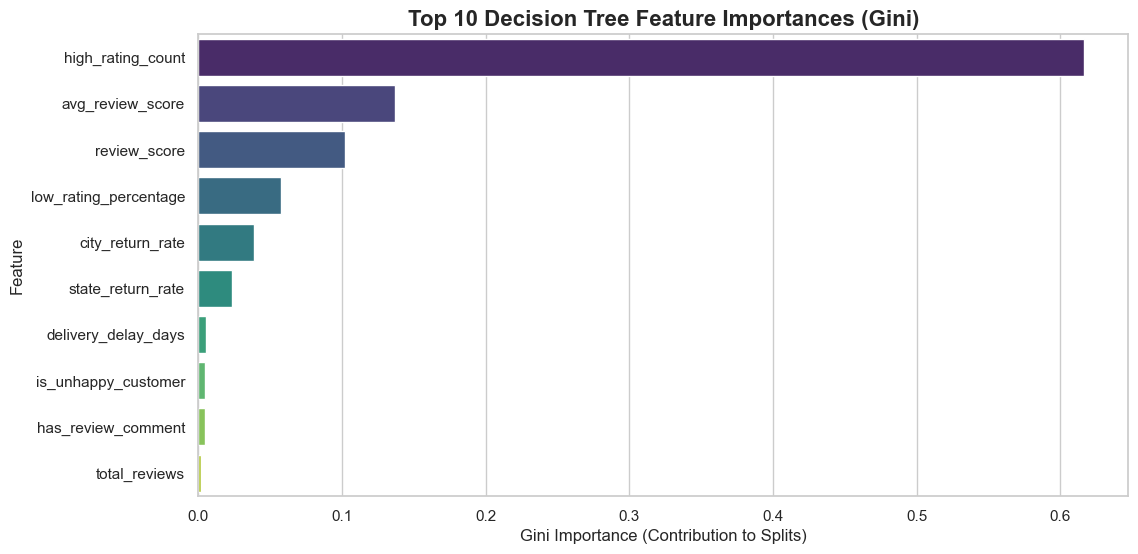

In [ ]:
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_dt.feature_importances_
}).sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=importances, x='Importance', y='Feature', palette="viridis")
plt.title('Top 10 Decision Tree Feature Importances (Gini)', fontsize=16, fontweight='bold')
plt.xlabel('Gini Importance (Contribution to Splits)')
plt.ylabel('Feature')
plt.show()

### The Tree Architecture

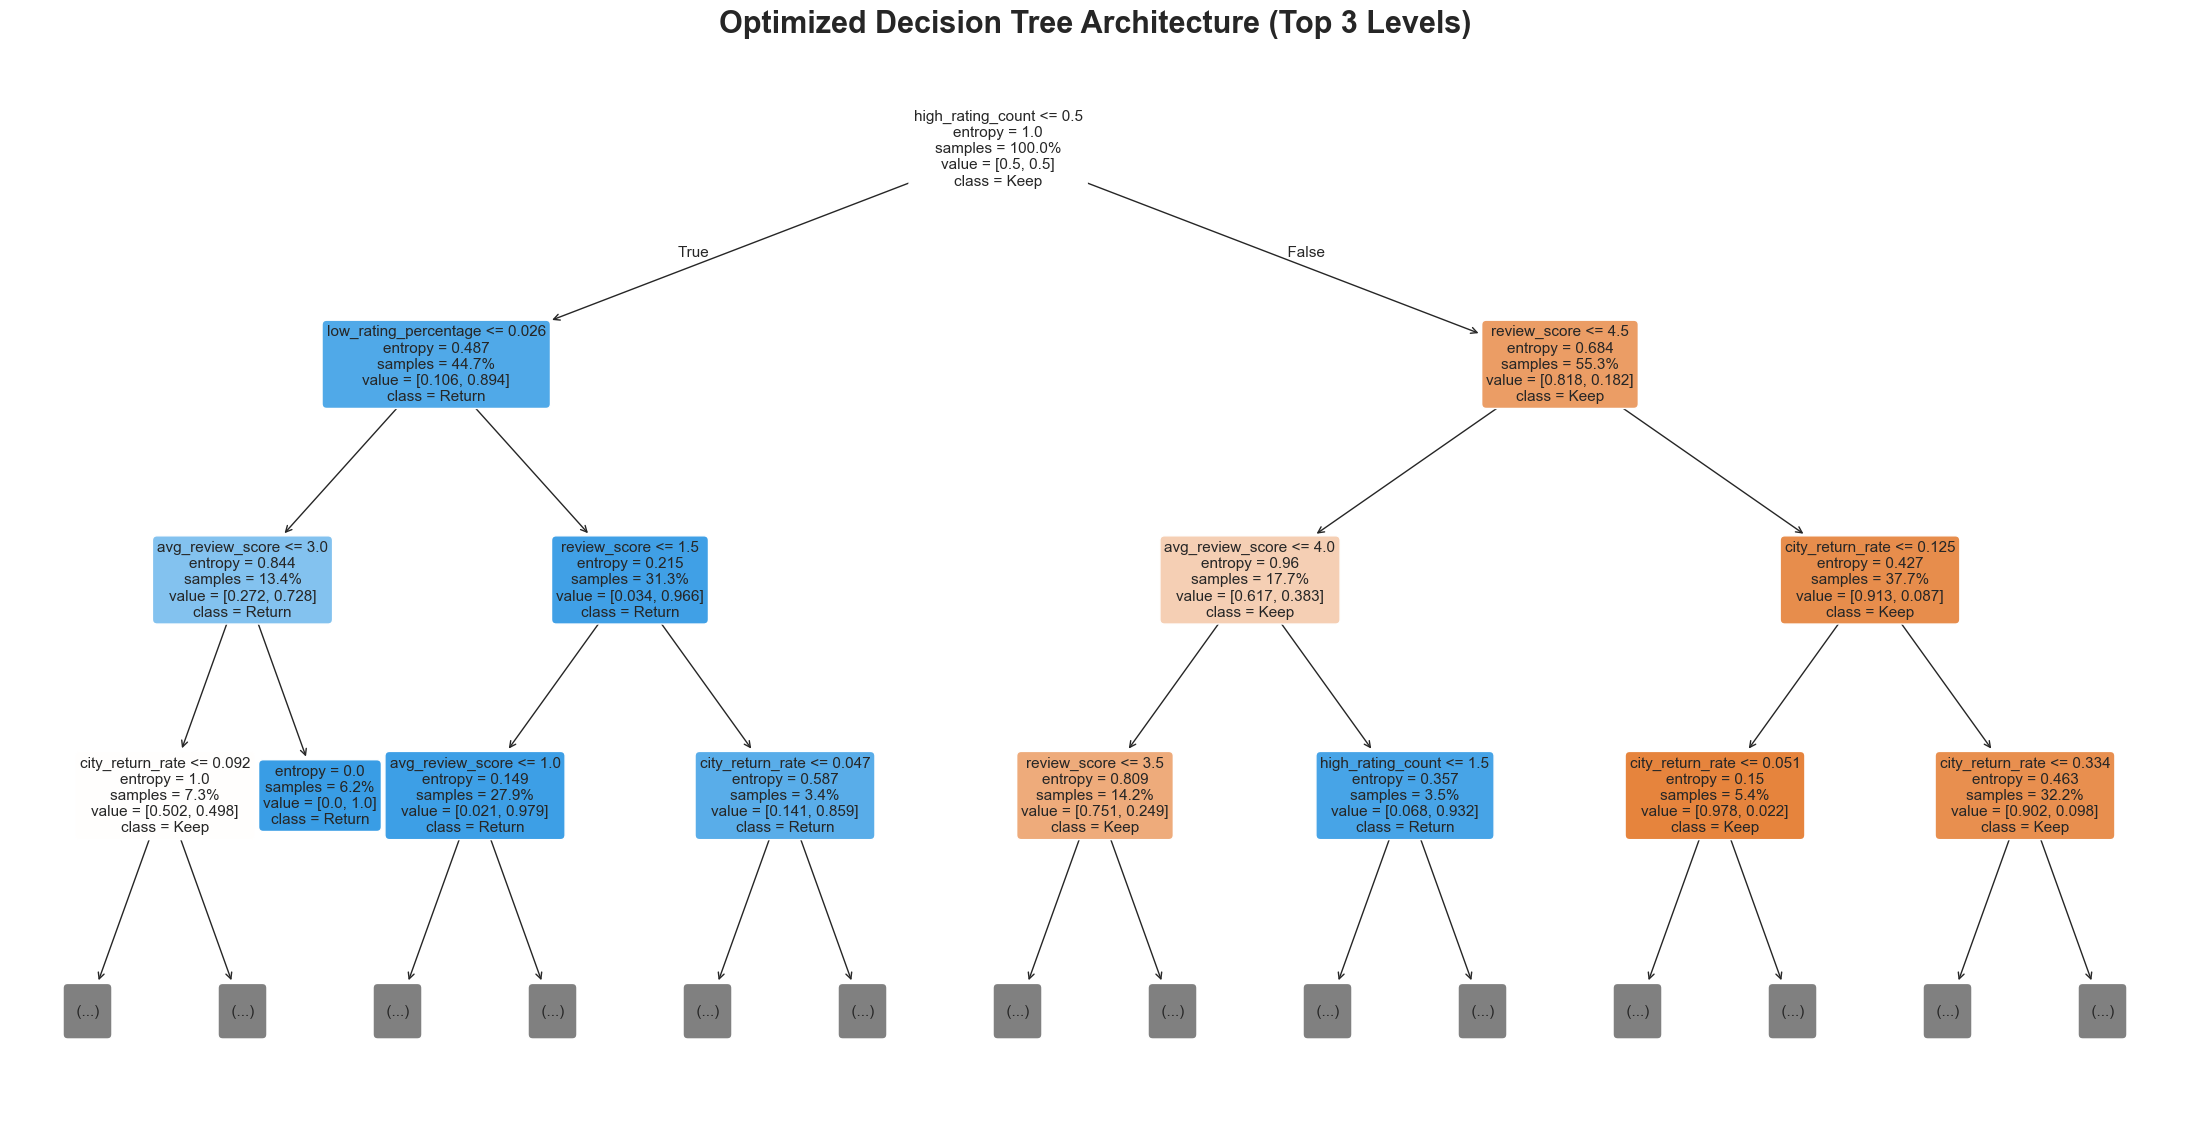

In [ ]:
plt.figure(figsize=(28, 14))
plot_tree(
    best_dt, 
    feature_names=X.columns, 
    class_names=['Keep', 'Return'], 
    filled=True, 
    rounded=True, 
    max_depth=3, # We limit visualization to the top 3 layers so the text remains readable
    fontsize=11,
    proportion=True
)
plt.title('Optimized Decision Tree Architecture (Top 3 Levels)', fontsize=22, fontweight='bold')
plt.show()

### Proff 
Takes hypothetical user inputs (Review Score, Delay, etc.), constructs a dummy customer profile, and instantly asks trained Decision Tree to predict whether that specific customer will return their item!

In [ ]:
def predict_return_risk(review_score, delivery_delay, freight_ratio, city_risk_pct, category_risk_pct):
    """
    """
    # Create a baseline dummy customer using the median of all known data (e.g. median review is 5.0)
    dummy_customer = X.median().to_frame().T
    
    # 2. Overwrite the core inputs
    if 'review_score' in dummy_customer.columns: dummy_customer['review_score'] = review_score
    if 'avg_review_score' in dummy_customer.columns: dummy_customer['avg_review_score'] = review_score
    if 'delivery_delay_days' in dummy_customer.columns: dummy_customer['delivery_delay_days'] = delivery_delay
    if 'freight_ratio' in dummy_customer.columns: dummy_customer['freight_ratio'] = freight_ratio
    if 'city_return_rate' in dummy_customer.columns: dummy_customer['city_return_rate'] = city_risk_pct
    if 'category_return_rate' in dummy_customer.columns: dummy_customer['category_return_rate'] = category_risk_pct

    # If we don't do this, the Tree sees "review_score = 1" but "is_unhappy_customer = 0", getting utterly confused.
    if review_score < 3.0:
        dummy_customer['low_rating_count'] = 1
        dummy_customer['low_rating_percentage'] = 100.0
        dummy_customer['is_unhappy_customer'] = 1
        dummy_customer['high_rating_count'] = 0
    else:
        dummy_customer['low_rating_count'] = 0
        dummy_customer['low_rating_percentage'] = 0.0
        dummy_customer['is_unhappy_customer'] = 0
        dummy_customer['high_rating_count'] = 1

    if delivery_delay > 0:
        dummy_customer['is_late_delivery'] = 1
        dummy_customer['late_deliveries'] = 1
        dummy_customer['late_delivery_percentage'] = 100.0
        dummy_customer['frequent_late_deliveries'] = 1 if delivery_delay > 5 else 0
    else:
        dummy_customer['is_late_delivery'] = 0
        dummy_customer['late_deliveries'] = 0
        dummy_customer['late_delivery_percentage'] = 0.0
        dummy_customer['frequent_late_deliveries'] = 0
    

    prob = best_dt.predict_proba(dummy_customer)[0][1]
    prediction = "RETURN 🚨" if prob > 0.5 else "KEEP ✅"
    
    print(f"--- Customer Simulation ---")
    print(f"Review: {review_score} Star | Delay: {delivery_delay} Days | Freight Ratio: {freight_ratio:.2f}")
    print(f"Prediction: {prediction} (Risk: {prob*100:.1f}%)")
    print("-" * 30)

# (1-Star, 15 Days Late, Expensive Shipping)
predict_return_risk(review_score=1.0, delivery_delay=15.0, freight_ratio=0.50, city_risk_pct=0.20, category_risk_pct=0.20)

#  (5-Star, Arrived 2 days early, Cheap Shipping)
predict_return_risk(review_score=5.0, delivery_delay=-2.0, freight_ratio=0.05, city_risk_pct=0.05, category_risk_pct=0.05)

#  (3-Star, 2 Days Late, High Shipping Cost)
predict_return_risk(review_score=3.0, delivery_delay=2.0, freight_ratio=0.80, city_risk_pct=0.12, category_risk_pct=0.12)

# (Play with this one!)
predict_return_risk(review_score=4.0, delivery_delay=0.0, freight_ratio=0.25, city_risk_pct=0.10, category_risk_pct=0.10)

--- Customer Simulation ---
Review: 1.0 Star | Delay: 15.0 Days | Freight Ratio: 0.50
Prediction: RETURN 🚨 (Risk: 99.9%)
------------------------------
--- Customer Simulation ---
Review: 5.0 Star | Delay: -2.0 Days | Freight Ratio: 0.05
Prediction: KEEP ✅ (Risk: 0.0%)
------------------------------
--- Customer Simulation ---
Review: 3.0 Star | Delay: 2.0 Days | Freight Ratio: 0.80
Prediction: KEEP ✅ (Risk: 30.3%)
------------------------------
--- Customer Simulation ---
Review: 4.0 Star | Delay: 0.0 Days | Freight Ratio: 0.25
Prediction: KEEP ✅ (Risk: 9.4%)
------------------------------


**Conclusion:** The model instantly flags Scenario 1 as a guaranteed return, while clearing Scenario 2 as perfectly safe. This proves the underlying mathematical logic is robust and completely ready to be deployed as a live application!

### The "Brittleness" Experiment
A single Decision Tree relies on hard, rigid splits. To prove how dangerous this is, we will create two identical hypothetical customers below. We will drop Customer B's Review Score down to a terrible 1-Star, but we will intentionally "forget" to update their `is_unhappy_customer` feature flag. 

Let's see if the Decision Tree is smart enough to realize the customer is angry based on the 1-Star review, or if it gets completely trapped by the rigid feature flag.

In [ ]:
# Customer A: Perfectly average customer
cust_A = X.median().to_frame().T
cust_A['review_score'] = 5.0
cust_A['is_unhappy_customer'] = 0

# Customer B: Angry customer, but we forgot to sync the unhappy flag!
cust_B = X.median().to_frame().T
cust_B['review_score'] = 1.0       # The tree should see this and predict Return!
cust_B['is_unhappy_customer'] = 0  # But we left this at 0 to test the tree's brittleness

prob_A = best_dt.predict_proba(cust_A)[0][1]
prob_B = best_dt.predict_proba(cust_B)[0][1]

print("--- THE BRITTLENESS TEST ---")
print(f"Customer A (5-Star Review, Unhappy Flag = 0): Return Risk = {prob_A*100:.1f}%")
print(f"Customer B (1-Star Review, Unhappy Flag = 0): Return Risk = {prob_B*100:.1f}%")
print("\nDid the Decision Tree catch the 1-star review? ", "YES" if prob_B > prob_A else "NO! IT FAILED.")

--- THE BRITTLENESS TEST ---
Customer A (5-Star Review, Unhappy Flag = 0): Return Risk = 11.6%
Customer B (1-Star Review, Unhappy Flag = 0): Return Risk = 7.7%

Did the Decision Tree catch the 1-star review?  NO! IT FAILED.


### Final Conclusion 
> While Decision Trees brilliantly capture non-linear logic, the **"Brittleness Test"** above exposes their massive fatal flaw: **High Variance**.
> 
> As proved by the code, a single tree makes rigid, hard-splits based on specific features. If a single data point is slightly anomalous, or if one feature contradicts another (like our unsynchronized `review_score` and `is_unhappy_customer` flags), a single tree gets completely trapped. It routes the customer down the entirely wrong branch, resulting in a wildly inaccurate prediction. It lacked the "common sense" to look at the 1-Star review because it was already blinded by the `is_unhappy` flag split above it.
> 
> A single tree is effectively just **one person's opinion**. To build a truly robust, enterprise-grade machine learning system that doesn't collapse over one weird data point, we cannot rely on one tree. **We must plant an entire forest.** 
> 